# Experiment 9 — Standard ReLU vs BatchTopK recovery

This standalone plotting notebook compares the five-seed Standard ReLU and BatchTopK SAE experiments across `N = 2, 4, ..., 256`. It creates two figures:

1. median Hungarian 90% recovery and median MMCS;
2. mean Hungarian 90% recovery and mean MMCS.

Each figure contains both SAE architectures on the same subplot for each metric, with legends. No SAE training or checkpoint loading is required.


## Repository and data paths

The notebook works when launched from the repository root or `composed-features/`. In Colab it uses `/content/SAE`, cloning the GitHub repository there only when necessary. Google Drive is not mounted or used. Both PNGs are written to the repository's `evans/` directory.


In [1]:
from __future__ import annotations

import importlib.util
import subprocess
from pathlib import Path

try:
    IN_COLAB = importlib.util.find_spec('google.colab') is not None
except ModuleNotFoundError:
    IN_COLAB = False

COLAB_REPOSITORY_URL = 'https://github.com/Adefioye/SAE.git'
COLAB_REPOSITORY_ROOT = Path('/content/SAE')


def is_repository_root(path: Path) -> bool:
    return (
        (path / 'composed-features').is_dir()
        and (path / 'evans').is_dir()
    )


def find_repository_root(start: Path) -> Path | None:
    candidates = (start, *start.parents)
    return next((path for path in candidates if is_repository_root(path)), None)


if IN_COLAB:
    if not is_repository_root(COLAB_REPOSITORY_ROOT):
        if COLAB_REPOSITORY_ROOT.exists() and any(COLAB_REPOSITORY_ROOT.iterdir()):
            raise FileExistsError(
                f'{COLAB_REPOSITORY_ROOT} exists but is not the SAE repository.'
            )
        COLAB_REPOSITORY_ROOT.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            ['git', 'clone', '--depth', '1', COLAB_REPOSITORY_URL,
             str(COLAB_REPOSITORY_ROOT)],
            check=True,
        )
    REPOSITORY_ROOT = COLAB_REPOSITORY_ROOT
else:
    REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())

if REPOSITORY_ROOT is None or not is_repository_root(REPOSITORY_ROOT):
    raise FileNotFoundError(
        'Could not locate the SAE repository. Run this notebook from the '
        'repository root or composed-features directory.'
    )

REPOSITORY_ROOT = REPOSITORY_ROOT.resolve()
RELU_RESULTS_PATH = (
    REPOSITORY_ROOT
    / 'composed-features/artifacts/03_sparse_factorial_antipodal/results'
    / 'optimized_hparams_125m_5_seed_n_sweep_generated_antipodal_v1__lr-0p0004__l1-0p1'
    / 'per_seed_results.csv'
)
BATCHTOPK_RESULTS_PATH = (
    REPOSITORY_ROOT
    / 'composed-features/artifacts/08_batchtopk_sae/results'
    / 'experiment_8b_batchtopk_per_seed_125m__lr-0p000175__k-2.csv'
)
OUTPUT_DIRECTORY = REPOSITORY_ROOT / 'evans'
MEDIAN_PLOT_PATH = OUTPUT_DIRECTORY / 'standard-relu-vs-batchtopk-median-recovery-by-n.png'
MEAN_PLOT_PATH = OUTPUT_DIRECTORY / 'standard-relu-vs-batchtopk-mean-recovery-by-n.png'

for result_path in (RELU_RESULTS_PATH, BATCHTOPK_RESULTS_PATH):
    if not result_path.is_file():
        raise FileNotFoundError(f'Missing result CSV: {result_path}')
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print('Runtime:', 'Google Colab' if IN_COLAB else 'local Jupyter')
print('Repository:', REPOSITORY_ROOT)
print('Standard ReLU CSV:', RELU_RESULTS_PATH)
print('BatchTopK CSV:', BATCHTOPK_RESULTS_PATH)
print('Output directory:', OUTPUT_DIRECTORY)


Runtime: local Jupyter
Repository: /Users/abdulhakeemadefioye/Desktop/SAE
Standard ReLU CSV: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/optimized_hparams_125m_5_seed_n_sweep_generated_antipodal_v1__lr-0p0004__l1-0p1/per_seed_results.csv
BatchTopK CSV: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/08_batchtopk_sae/results/experiment_8b_batchtopk_per_seed_125m__lr-0p000175__k-2.csv
Output directory: /Users/abdulhakeemadefioye/Desktop/SAE/evans


## Imports and editable plot settings

Change the labels, titles, colors, markers, dimensions, or legend position in this cell.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

EXPECTED_N_VALUES = (2, 4, 8, 16, 32, 64, 128, 256)
EXPECTED_SAE_SEEDS = frozenset(range(5))

SERIES_LABELS = {
    'relu': 'Standard ReLU SAE',
    'batchtopk': 'BatchTopK SAE (k=2)',
}
SERIES_STYLES = {
    'relu': {'color': '#1f77b4', 'marker': 'o'},
    'batchtopk': {'color': '#d95f02', 'marker': 's'},
}

FIGURE_SIZE = (14, 5.4)
FIGURE_DPI = 220
LINE_WIDTH = 2.4
MARKER_SIZE = 7
LEGEND_LOCATION = 'lower right'
Y_LIMITS = (-0.03, 1.03)

FIGURE_TITLE_TEMPLATE = (
    'Standard ReLU vs BatchTopK SAE — {statistic} across five seeds'
)
HUNGARIAN_SUBPLOT_TITLE = 'Hungarian alignment — 90% cutoff'
MMCS_SUBPLOT_TITLE = 'Mean Max Cosine Similarity (MMCS)'
X_AXIS_LABEL = 'Number of features per set (N)'
HUNGARIAN_Y_AXIS_TEMPLATE = '{statistic} recovery fraction'
MMCS_Y_AXIS_TEMPLATE = '{statistic} MMCS'

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
})


## Load and validate the five-seed results

Validation prevents the older 128M ReLU results or incomplete seed groups from being mixed into this 125M comparison.


In [3]:
REQUIRED_COLUMNS = {
    'n_per_set', 'sae_seed', 'dictionary_seed', 'data_seed',
    'training_samples', 'train_batch_size', 'learning_rate',
    'hungarian_90', 'mmcs',
}


def load_and_validate_results(
    path: Path,
    *,
    architecture: str,
    expected_learning_rate: float,
    expected_l1: float | None = None,
    expected_k: float | None = None,
) -> pd.DataFrame:
    frame = pd.read_csv(path)
    missing = REQUIRED_COLUMNS.difference(frame.columns)
    if missing:
        raise ValueError(f'{architecture} CSV is missing: {sorted(missing)}')
    if frame[['hungarian_90', 'mmcs']].isna().any().any():
        raise ValueError(f'{architecture} CSV has missing recovery metrics.')
    if frame.duplicated(['n_per_set', 'sae_seed']).any():
        raise ValueError(f'{architecture} CSV has duplicate N/seed rows.')

    expected_values = {
        'training_samples': 125_000_000,
        'train_batch_size': 16_384,
        'dictionary_seed': 0,
        'data_seed': 0,
        'learning_rate': expected_learning_rate,
    }
    if expected_l1 is not None:
        if 'l1_coefficient' not in frame.columns:
            raise ValueError(f'{architecture} CSV lacks l1_coefficient.')
        expected_values['l1_coefficient'] = expected_l1
    if expected_k is not None:
        if 'k' not in frame.columns:
            raise ValueError(f'{architecture} CSV lacks k.')
        expected_values['k'] = expected_k

    for column, expected in expected_values.items():
        observed = frame[column].astype(float)
        if not observed.eq(float(expected)).all():
            raise ValueError(
                f'{architecture} CSV has incompatible {column}: '
                f'{sorted(observed.unique())}'
            )

    observed_n = tuple(sorted(frame['n_per_set'].astype(int).unique()))
    if observed_n != EXPECTED_N_VALUES:
        raise ValueError(
            f'{architecture} has N={observed_n}; expected {EXPECTED_N_VALUES}.'
        )
    for n_per_set, group in frame.groupby('n_per_set'):
        observed_seeds = frozenset(group['sae_seed'].astype(int))
        if observed_seeds != EXPECTED_SAE_SEEDS or len(group) != 5:
            raise ValueError(
                f'{architecture}, N={int(n_per_set)} has seeds '
                f'{sorted(observed_seeds)}; expected seeds 0–4 exactly once.'
            )
    return frame.sort_values(['n_per_set', 'sae_seed']).reset_index(drop=True)


relu_results = load_and_validate_results(
    RELU_RESULTS_PATH,
    architecture='Standard ReLU SAE',
    expected_learning_rate=4e-4,
    expected_l1=0.1,
)
batchtopk_results = load_and_validate_results(
    BATCHTOPK_RESULTS_PATH,
    architecture='BatchTopK SAE',
    expected_learning_rate=1.75e-4,
    expected_k=2.0,
)
RESULTS_BY_ARCHITECTURE = {
    'relu': relu_results,
    'batchtopk': batchtopk_results,
}

print('Validated 40 rows (8 N values × 5 seeds) for each SAE.')


Validated 40 rows (8 N values × 5 seeds) for each SAE.


## Reusable aggregation and plotting functions


In [4]:
def aggregate_recovery(
    frame: pd.DataFrame, statistic: str
) -> pd.DataFrame:
    if statistic not in {'median', 'mean'}:
        raise ValueError("statistic must be 'median' or 'mean'.")
    grouped = frame.groupby('n_per_set')[['hungarian_90', 'mmcs']]
    aggregate = getattr(grouped, statistic)()
    return aggregate.reset_index().sort_values('n_per_set')


def plot_recovery_comparison(
    *, statistic: str, output_path: Path
) -> tuple[plt.Figure, list[plt.Axes], dict[str, pd.DataFrame]]:
    statistic_label = statistic.capitalize()
    aggregated = {
        architecture: aggregate_recovery(frame, statistic)
        for architecture, frame in RESULTS_BY_ARCHITECTURE.items()
    }
    figure, axes_array = plt.subplots(
        1, 2, figsize=FIGURE_SIZE, constrained_layout=True
    )
    axes = list(axes_array)
    metric_settings = (
        (
            'hungarian_90',
            HUNGARIAN_SUBPLOT_TITLE,
            HUNGARIAN_Y_AXIS_TEMPLATE.format(statistic=statistic_label),
        ),
        (
            'mmcs',
            MMCS_SUBPLOT_TITLE,
            MMCS_Y_AXIS_TEMPLATE.format(statistic=statistic_label),
        ),
    )

    for axis, (metric, title, y_label) in zip(axes, metric_settings, strict=True):
        for architecture, aggregate in aggregated.items():
            axis.plot(
                aggregate['n_per_set'],
                aggregate[metric],
                label=SERIES_LABELS[architecture],
                linewidth=LINE_WIDTH,
                markersize=MARKER_SIZE,
                **SERIES_STYLES[architecture],
            )
        axis.set_xscale('log', base=2)
        axis.set_xticks(EXPECTED_N_VALUES)
        axis.set_xticklabels([str(value) for value in EXPECTED_N_VALUES])
        axis.set_xlabel(X_AXIS_LABEL)
        axis.set_ylabel(y_label)
        axis.set_title(title)
        axis.set_ylim(*Y_LIMITS)
        axis.grid(True, alpha=0.25)
        axis.legend(loc=LEGEND_LOCATION, frameon=True)

    figure.suptitle(
        FIGURE_TITLE_TEMPLATE.format(statistic=statistic_label),
        fontsize=17,
    )
    figure.savefig(
        output_path, dpi=FIGURE_DPI, bbox_inches='tight', facecolor='white'
    )
    print('Saved:', output_path)
    return figure, axes, aggregated


## Median across five SAE seeds

This cell replots and overwrites the median comparison PNG in `evans/`.


Saved: /Users/abdulhakeemadefioye/Desktop/SAE/evans/standard-relu-vs-batchtopk-median-recovery-by-n.png


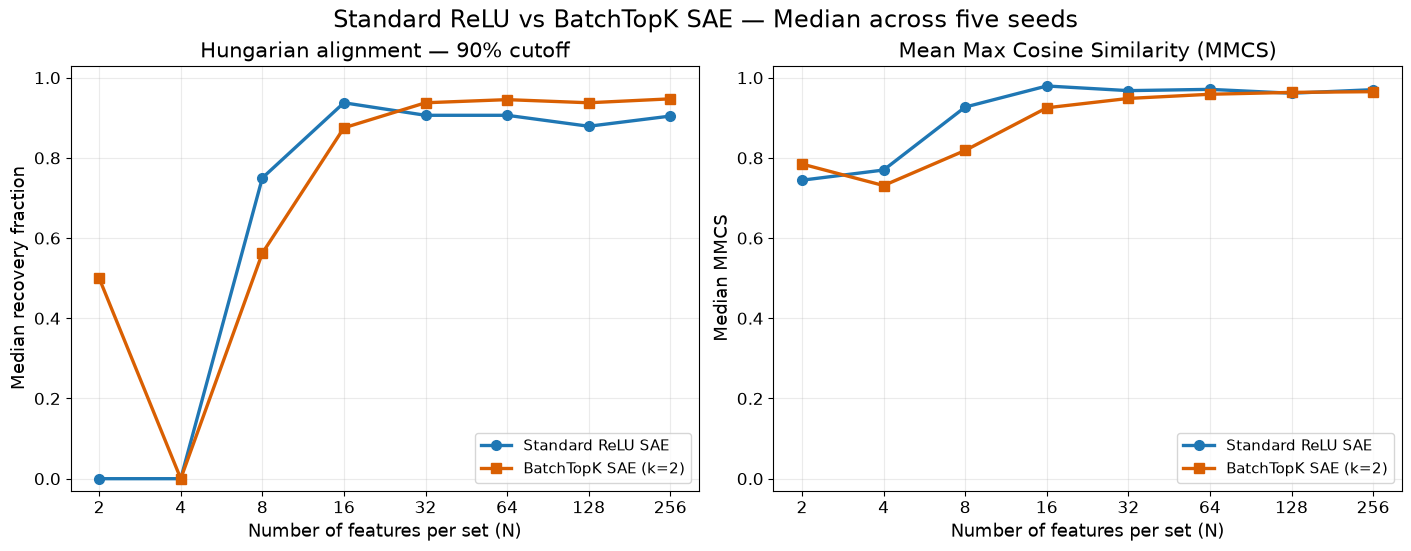


 Standard ReLU SAE


,n_per_set,hungarian_90,mmcs
0,2,0.000000,0.744405
1,4,0.000000,0.769737
2,8,0.750000,0.926800
3,16,0.937500,0.979349
4,32,0.906250,0.967747
5,64,0.906250,0.970923
6,128,0.878906,0.961302
7,256,0.904297,0.970162



 BatchTopK SAE (k=2)


,n_per_set,hungarian_90,mmcs
0,2,0.500000,0.784668
1,4,0.000000,0.731069
2,8,0.562500,0.818633
3,16,0.875000,0.924968
4,32,0.937500,0.948289
5,64,0.945312,0.958715
6,128,0.937500,0.963418
7,256,0.947266,0.965148


In [5]:
median_figure, median_axes, median_results = plot_recovery_comparison(
    statistic='median',
    output_path=MEDIAN_PLOT_PATH,
)
plt.show()

for architecture, frame in median_results.items():
    print('\n', SERIES_LABELS[architecture])
    display(frame)


## Mean across five SAE seeds

This cell creates the corresponding mean comparison PNG in `evans/`.


Saved: /Users/abdulhakeemadefioye/Desktop/SAE/evans/standard-relu-vs-batchtopk-mean-recovery-by-n.png


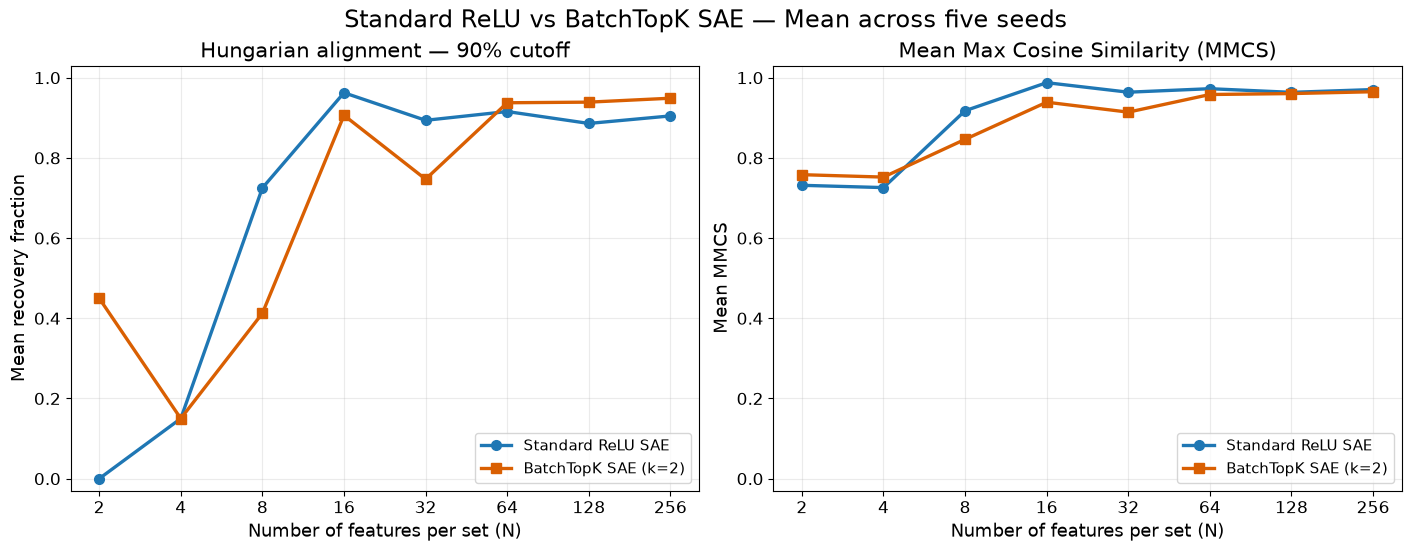


 Standard ReLU SAE


,n_per_set,hungarian_90,mmcs
0,2,0.000000,0.731642
1,4,0.150000,0.725941
2,8,0.725000,0.917614
3,16,0.962500,0.987602
4,32,0.893750,0.963859
5,64,0.915625,0.972569
6,128,0.885938,0.963511
7,256,0.904687,0.970454



 BatchTopK SAE (k=2)


,n_per_set,hungarian_90,mmcs
0,2,0.450000,0.758153
1,4,0.150000,0.752147
2,8,0.412500,0.846275
3,16,0.906250,0.938923
4,32,0.746875,0.914112
5,64,0.937500,0.958093
6,128,0.939063,0.960431
7,256,0.948828,0.965018


In [6]:
mean_figure, mean_axes, mean_results = plot_recovery_comparison(
    statistic='mean',
    output_path=MEAN_PLOT_PATH,
)
plt.show()

for architecture, frame in mean_results.items():
    print('\n', SERIES_LABELS[architecture])
    display(frame)
